### Data processing

Input: `data/raw/movie_raw.csv` - dữ liệu thô sau khi thu thập, lọc và merge.

In [71]:
import pandas as pd
import numpy as np
import os
import ast
import warnings
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, MultiLabelBinarizer

warnings.filterwarnings('ignore')

CURRENT_DIR = os.getcwd()
DATA_PATH = os.path.join(CURRENT_DIR, '..', 'data')
RAW_DATA_PATH = os.path.join(DATA_PATH, 'raw')
INTERIM_DATA_PATH = os.path.join(DATA_PATH, 'interim')
PROCESSED_DATA_PATH = os.path.join(DATA_PATH, 'processed')

raw_data = os.path.join(RAW_DATA_PATH, 'movie_raw.csv')

df = pd.read_csv(raw_data)

print("Shape ban đầu:", df.shape)
print("Data Types:")
print(df.dtypes)

Shape ban đầu: (6182, 14)
Data Types:
tconst                      str
startYear                 int64
runtimeMinutes          float64
budget                  float64
revenue                 float64
production_companies        str
original_language           str
origin_country              str
top_3_cast                  str
director                    str
keywords                    str
genres                      str
certification_us            str
release_date                str
dtype: object


In [72]:
# Parse list columns
list_cols = ['production_companies', 'origin_country', 'genres', 'keywords']
for col in list_cols:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])

dict_cols = ['top_3_cast', 'director']
for col in dict_cols:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])

# Parse datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

print("Data Types:")
print(df.dtypes)
# Thống kê sơ bộ
def count_true_missing(series):
    # Đếm NaN thông thường
    if series.dtype != 'object':
        return series.isnull().sum()
    
    # Đếm các giá trị list/dict bị rỗng [] hoặc {} sau khi parse
    empty_count = series.apply(lambda x: 1 if (isinstance(x, (list, dict)) and len(x) == 0) else 0).sum()
    nan_count = series.isnull().sum()
    return empty_count + nan_count

missing_stats = []
for col in df.columns:
    missing_val = count_true_missing(df[col])
    missing_stats.append({
        'Column': col,
        'Missing Count': missing_val,
        'Missing %': (missing_val / len(df)) * 100
    })

missing_info = pd.DataFrame(missing_stats).set_index('Column')
print(missing_info)

Data Types:
tconst                             str
startYear                        int64
runtimeMinutes                 float64
budget                         float64
revenue                        float64
production_companies            object
original_language                  str
origin_country                  object
top_3_cast                      object
director                        object
keywords                        object
genres                          object
certification_us                   str
release_date            datetime64[us]
dtype: object
                      Missing Count  Missing %
Column                                        
tconst                            0   0.000000
startYear                         0   0.000000
runtimeMinutes                    0   0.000000
budget                         3538  57.230670
revenue                        3005  48.608864
production_companies             98   1.585247
original_language                 3   0.048528
origi

Tỉ lệ missing cao nhất ở budget và revenue. Đây là 2 biến cấu thành biến mục tiêu theo dự định (profitable). Biến mục tiêu là yếu tố quyết định của bài toán học có giám sát. Việc nội suy (impute) doanh thu hoặc ngân sách sẽ làm sai lệch thực tế và khiến mô hình học sai bản chất. Quyết định drop, lưu lại các dòng bị drop để đánh giá mức độ selection bias.

In [73]:
# Lọc missing budget/revenue

total_movies = len(df)
missing_budget = df['budget'].isnull().sum()
missing_revenue = df['revenue'].isnull().sum()
missing_either = (df['budget'].isnull() | df['revenue'].isnull()).sum()

print(f"Tổng phim: {total_movies}")
print(f"Thiếu budget: {missing_budget}")
print(f"Thiếu revenue: {missing_revenue}")
print(f"Thiếu 1 trong 2: {missing_either}")

mask_drop = df['budget'].isnull() | df['revenue'].isnull()
df_kept = df[~mask_drop]
df_dropped = df[mask_drop]

df_kept.to_csv(os.path.join(INTERIM_DATA_PATH, 'df_kept_financials.csv'), index=False)
df_dropped.to_csv(os.path.join(INTERIM_DATA_PATH, 'df_dropped_financials.csv'), index=False)
print("Đã lưu df_kept và df_dropped vào data/interim/.")

df = df_kept.copy()
print(f"Shape sau khi drop missing financials: {df.shape}")

Tổng phim: 6182
Thiếu budget: 3538
Thiếu revenue: 3005
Thiếu 1 trong 2: 3956
Đã lưu df_kept và df_dropped vào data/interim/.
Shape sau khi drop missing financials: (2226, 14)


Tạo biến mục tiêu


$\text{profitable} =
\begin{cases}
1, & \text{nếu } \dfrac{\text{revenue}}{\text{budget}} \ge 2.5,\\[6pt]
0, & \text{nếu } \dfrac{\text{revenue}}{\text{budget}} < 2.5.
\end{cases}$

In [74]:
df['profitable'] = (df['revenue'] / df['budget'] >= 2.5).astype(int)
df = df.drop(columns=['revenue'])
print(df['profitable'].value_counts(normalize=True))

profitable
0    0.606469
1    0.393531
Name: proportion, dtype: float64


Dữ liệu không bị mất cân bằng nghiêm trọng, tỷ lệ nhãn chênh lệch có thể do thực tế thị trường. Thực hiện stratified split để đảm bảo train và test giữ đúng tỷ lệ

In [75]:
# Train/Test Split

y = df['profitable']
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Kiểm tra phân phối
print("Phân phối nhãn Train:")
print(df_train['profitable'].value_counts(normalize=True))
print("Phân phối nhãn Test:")
print(df_test['profitable'].value_counts(normalize=True))

df_train = df_train.copy()
df_test = df_test.copy()

Phân phối nhãn Train:
profitable
0    0.606742
1    0.393258
Name: proportion, dtype: float64
Phân phối nhãn Test:
profitable
0    0.605381
1    0.394619
Name: proportion, dtype: float64


In [76]:
# Lưu lại cho EDA

df_train.to_csv(os.path.join(INTERIM_DATA_PATH, 'movie_train_eda.csv'), index=False)
print("Đã lưu movie_train_eda.csv vào data/interim/.")

Đã lưu movie_train_eda.csv vào data/interim/.


**MISSING VALUE** (phân tích trong 03)

**OUTLIER** (phân tích trong 03)

*Vấn đề với cast_popularity và director_popularity*

Sau khi xem xét lại 2 biến này, nhóm nhận định tồn tại các vấn đề

- Temporal leakage: TMDB popularity là điểm real-time tại thời điểm gọi API, không phải tại thời điểm phim ra mắt. Một diễn viên nổi tiếng năm 2024 vì một bộ phim mới sẽ có điểm cao cho tất cả phim cũ của họ - kể cả phim từ năm 2005. Mô hình sẽ học được thông tin từ tương lai, dẫn đến sai lệch so với thực tế.

- Data inconsistency: Cùng một id cho ra điểm popularity khác nhau ở các dòng dữ liệu khác nhau trong cùng một lần query API. Nguyên nhân có thể do dữ liệu từ TMDB không đồng nhất giữa các phim. Sự không nhất quán này cho thấy dữ liệu không ổn định, không đảm bảo độ tin cậy và chất lượng.

Từ các lý do trên, nhóm quyết định drop 2 cột này để tránh đưa nhiễu vào mô hình.

In [77]:
df_train = df_train.drop(columns=['top_3_cast', 'director'])
df_test = df_test.drop(columns=['top_3_cast', 'director'])

Nhận thấy rằng trường startYear từ imdb có nguy cơ sai lệch do ngày ra mắt không phải chính thức. Do đó, nhóm quyết định drop cột startYear, thay thế bằng cột release_year sẽ trích xuất từ release_date

Thực hiện kiểm tra các giá trị release date nằm ngoài scope 2015-2025 (nghi vấn sẽ có một số phim 2026 do imdb lấy ngày ra mắt của film fes), và drop

In [78]:
df_train['release_year'] = df_train['release_date'].dt.year
df_test['release_year'] = df_test['release_date'].dt.year

df_train = df_train.drop(columns=['startYear'])
df_test = df_test.drop(columns=['startYear'])

def filter_by_year(df, col_name='release_year', min_year=2015, max_year=2025):
    condition = (df[col_name] < min_year) | (df[col_name] > max_year)
    outliers = df[condition]
    print(f"Loại bỏ {len(outliers)} dòng (năm < {min_year} hoặc > {max_year}).")
    if not outliers.empty:
        print(outliers[['tconst', col_name]].head().to_string(index=False))
    return df[~condition].copy()

print("train")
df_train = filter_by_year(df_train)
print("test")
df_test = filter_by_year(df_test)
print(f"\nKích thước sau lọc: Train={df_train.shape[0]}, Test={df_test.shape[0]}")

train
Loại bỏ 6 dòng (năm < 2015 hoặc > 2025).
    tconst  release_year
tt33028778          2026
tt35892608          2026
tt35522483          2026
tt37287335          2026
tt13570066          2026
test
Loại bỏ 2 dòng (năm < 2015 hoặc > 2025).
    tconst  release_year
 tt1341338          2026
tt15181326          2026

Kích thước sau lọc: Train=1774, Test=444


**FEATURE ENGINEERING**

Chuẩn hóa giá trị tiền tệ nhằm quy đổi ngân sách từ năm phát hành về sức mua tương đương của năm 2025, để loại bỏ sự sai lệch do thay đổi giá trị đồng tiền theo thời gian.

*Việc chuẩn hóa có thể thực hiện sau khi xác định biến mục tiêu từ việc chia revenue cho budget, nguyên nhân do phép biến đổi này nhân cả budget và revenue của từng dòng cho cùng một hệ số (được xác định từ năm của dòng đó) nên biến đổi trước hay sau thì tỉ lệ revenue/budget vẫn không đổi. Do đã drop revenue nên ở đây chỉ điều chỉnh cho budget*

In [79]:
# Inflation Adjustment

cpi_df = pd.read_csv(os.path.join(RAW_DATA_PATH, 'CPIAUCSL.csv'))
cpi_df['observation_date'] = pd.to_datetime(cpi_df['observation_date'])
cpi_df['year'] = cpi_df['observation_date'].dt.year

# Tính trung bình CPI theo năm
cpi_yearly = cpi_df.groupby('year')['CPIAUCSL'].mean().to_dict()
CPI_2025 = cpi_yearly.get(2025, None)

def adjust_inflation(row, col_name):
    if pd.isnull(row[col_name]):
        return np.nan
    year = int(row['release_year'])
    if year in cpi_yearly:
        factor = CPI_2025 / cpi_yearly[year]
        return row[col_name] * factor
    return row[col_name]

df_train['budget_adj'] = df_train.apply(lambda row: adjust_inflation(row, 'budget'), axis=1)
df_test['budget_adj'] = df_test.apply(lambda row: adjust_inflation(row, 'budget'), axis=1)

df_train = df_train.drop(columns=['budget'])
df_test = df_test.drop(columns=['budget'])

In [80]:
# 1. Extract release_month từ release_date
# Impute missing nếu có bằng mode theo release_year (fit trên train only)

df_train['release_month'] = df_train['release_date'].dt.month
df_test['release_month'] = df_test['release_date'].dt.month

# Tính mode theo năm từ train
month_mode_by_year = (
    df_train.groupby('release_year')['release_month']
    .agg(lambda x: x.mode()[0] if x.notna().sum() > 0 else np.nan)
    .to_dict()
)
global_month_mode = int(df_train['release_month'].mode()[0])

def impute_month(row):
    if pd.isna(row['release_month']):
        return month_mode_by_year.get(row['release_year'], global_month_mode)
    return row['release_month']

df_train['release_month'] = df_train.apply(impute_month, axis=1).astype(int)
df_test['release_month'] = df_test.apply(impute_month, axis=1).astype(int)

df_train = df_train.drop(columns=['release_date'])
df_test = df_test.drop(columns=['release_date'])

In [81]:
# 2. primary_country từ origin_country (chuyển từ list country thành 1 nước)
# Logic ưu tiên: khớp ngôn ngữ → top box office markets → fallback phần tử đầu
# Chọn 1 country đại diện cho thị trường chính của phim

LANG_TO_COUNTRY_MAP = {
    'en': ['US', 'GB', 'AU', 'CA', 'NZ', 'IE'],
    'zh': ['CN', 'HK', 'TW', 'SG'], 'cn': ['CN', 'HK', 'TW', 'SG'], 'yue': ['HK', 'CN'],
    'hi': ['IN'], 'ta': ['IN'], 'te': ['IN'], 'ml': ['IN'], 'kn': ['IN'],
    'bn': ['IN', 'BD'], 'pa': ['IN'], 'ur': ['IN', 'PK'],
    'fr': ['FR', 'BE', 'CH', 'CA'],
    'es': ['ES', 'MX', 'AR', 'CO', 'CL', 'PE'],
    'de': ['DE', 'AT', 'CH'],
    'pt': ['BR', 'PT'],
    'it': ['IT'],
    'ru': ['RU', 'BY', 'KZ'],
    'nl': ['NL', 'BE'],
    'sv': ['SE'], 'da': ['DK'], 'no': ['NO'], 'fi': ['FI'],
    'pl': ['PL'], 'tr': ['TR'], 'cs': ['CZ'], 'hu': ['HU'], 'el': ['GR'],
    'ja': ['JP'], 'ko': ['KR'], 'th': ['TH'], 'vi': ['VN'], 'id': ['ID'],
    'tl': ['PH'], 'ms': ['MY', 'SG'],
    'ar': ['EG', 'SA', 'AE', 'LB', 'MA'], 'fa': ['IR'], 'he': ['IL']
}
BOX_OFFICE_PRIORITY = ['US', 'CN', 'JP', 'IN', 'GB', 'FR', 'DE', 'MX', 'KR', 'AU']

def get_primary_country(row):
    countries = row['origin_country']
    lang = row['original_language']
    if not isinstance(countries, list) or len(countries) == 0:
        return 'Unknown'
    if len(countries) == 1:
        return countries[0]
    # Ưu tiên 1: khớp ngôn ngữ
    lang_matches = LANG_TO_COUNTRY_MAP.get(lang, [])
    for c in lang_matches:
        if c in countries:
            return c
    # Ưu tiên 2: top box office
    for c in BOX_OFFICE_PRIORITY:
        if c in countries:
            return c
    # Fallback: phần tử đầu
    return countries[0]

df_train['primary_country'] = df_train.apply(get_primary_country, axis=1)
df_test['primary_country'] = df_test.apply(get_primary_country, axis=1)

print("primary_country value counts (top 10):")
print(df_train['primary_country'].value_counts().head(10))
df_train = df_train.drop(columns=['origin_country'])
df_test = df_test.drop(columns=['origin_country'])

primary_country value counts (top 10):
primary_country
US    1201
IN     177
FR      77
GB      72
KR      32
ES      28
JP      20
CN      20
IT      19
CA      16
Name: count, dtype: int64


In [82]:
print(df_train.info())

<class 'pandas.DataFrame'>
Index: 1774 entries, 269 to 4998
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tconst                1774 non-null   str    
 1   runtimeMinutes        1774 non-null   float64
 2   production_companies  1774 non-null   object 
 3   original_language     1774 non-null   str    
 4   keywords              1774 non-null   object 
 5   genres                1774 non-null   object 
 6   certification_us      1516 non-null   str    
 7   profitable            1774 non-null   int64  
 8   release_year          1774 non-null   int32  
 9   budget_adj            1774 non-null   float64
 10  release_month         1774 non-null   int64  
 11  primary_country       1774 non-null   str    
dtypes: float64(2), int32(1), int64(2), object(3), str(4)
memory usage: 173.2+ KB
None


**ENCODING**

In [83]:
print(df_train['certification_us'].value_counts(dropna=False))

certification_us
R        718
PG-13    485
NaN      258
PG       199
NR       111
G          3
Name: count, dtype: int64


Gom 2 nhãn có ít sample vào chung với nhãn tương đồng (G và PG, NC-17 và R)

In [84]:
# 1. certification_us - OHE + flag

# has_us_cert = 0 với các dòng miss
df_train['has_us_cert'] = df_train['certification_us'].notna().astype(int)
df_test['has_us_cert'] = df_test['certification_us'].notna().astype(int)

# chuyển missing thành NR
df_train['certification_us'] = df_train['certification_us'].fillna('NR')
df_test['certification_us'] = df_test['certification_us'].fillna('NR')

cert_mapping = {
    'G': 'G_PG',
    'PG': 'G_PG',
    'R': 'R_NC-17',
    'NC-17': 'R_NC-17'
}
df_train['certification_us'] = df_train['certification_us'].replace(cert_mapping)
df_test['certification_us'] = df_test['certification_us'].replace(cert_mapping)

CERT_CATEGORIES = ['G_PG', 'PG-13', 'R_NC-17', 'NR']
df_train['certification_us'] = pd.Categorical(df_train['certification_us'], categories=CERT_CATEGORIES)
df_test['certification_us'] = pd.Categorical(df_test['certification_us'], categories=CERT_CATEGORIES)

df_train = pd.get_dummies(df_train, columns=['certification_us'], prefix='cert', dtype=int)
df_test = pd.get_dummies(df_test, columns=['certification_us'], prefix='cert', dtype=int)

cert_cols = [c for c in df_train.columns if c.startswith('cert_')]
print(df_train[cert_cols].sum())

cert_G_PG       202
cert_PG-13      485
cert_R_NC-17    718
cert_NR         369
dtype: int64


In [85]:
print("Số lượng language unique:", df_train['original_language'].nunique())

Số lượng language unique: 39


In [86]:
# 2. original_language — Group + One-Hot Encode
N_LANG = 3

total_unique_langs = df_train['original_language'].nunique()
lang_counts = df_train['original_language'].value_counts()
lang_pct = df_train['original_language'].value_counts(normalize=True) * 100
lang_cumsum = lang_pct.cumsum()

lang_summary = pd.DataFrame({
    'Count': lang_counts,
    'Percentage (%)': lang_pct,
    'Cumulative (%)': lang_cumsum
})

print(f"--- Thống kê phân phối & Cumulative Coverage (Top 10) ---")
print(lang_summary.head(10).round(2))

TOP_LANG_THRESHOLD = lang_summary.iloc[min(N_LANG, total_unique_langs)-1]['Count']
top_langs = lang_counts[lang_counts >= TOP_LANG_THRESHOLD].index.tolist()
coverage_percent = lang_cumsum.loc[top_langs[-1]] if top_langs else 0

print(f"Ngưỡng cắt: >= {TOP_LANG_THRESHOLD} phim")
print(f"Số lượng ngôn ngữ giữ lại: {len(top_langs)}/{total_unique_langs} ngôn ngữ {top_langs}")
print(f"Độ bao phủ: {coverage_percent:.2f}% toàn bộ dữ liệu Train.")

df_train['language_grouped'] = df_train['original_language'].apply(
    lambda x: x if x in top_langs else 'other'
)
df_test['language_grouped'] = df_test['original_language'].apply(
    lambda x: x if x in top_langs else 'other'
)

# OHE — fit trên train
ohe_lang = OneHotEncoder(dtype=int, sparse_output=False, handle_unknown='ignore')
lang_train = ohe_lang.fit_transform(df_train[['language_grouped']])
lang_test = ohe_lang.transform(df_test[['language_grouped']])
lang_cols = [f"lang_{c}" for c in ohe_lang.categories_[0]]

df_train[lang_cols] = lang_train
df_test[lang_cols] = lang_test
df_train = df_train.drop(columns=['original_language', 'language_grouped'])
df_test = df_test.drop(columns=['original_language', 'language_grouped'])

print(f"\nĐã tạo {len(lang_cols)} cột OHE cho language: {lang_cols}")

--- Thống kê phân phối & Cumulative Coverage (Top 10) ---
                   Count  Percentage (%)  Cumulative (%)
original_language                                       
en                  1325           74.69           74.69
hi                    98            5.52           80.21
fr                    69            3.89           84.10
ko                    31            1.75           85.85
es                    30            1.69           87.54
te                    29            1.63           89.18
ta                    27            1.52           90.70
ja                    19            1.07           91.77
zh                    18            1.01           92.78
it                    18            1.01           93.80
Ngưỡng cắt: >= 69.0 phim
Số lượng ngôn ngữ giữ lại: 3/39 ngôn ngữ ['en', 'hi', 'fr']
Độ bao phủ: 84.10% toàn bộ dữ liệu Train.

Đã tạo 4 cột OHE cho language: ['lang_en', 'lang_fr', 'lang_hi', 'lang_other']


In [87]:
print("Số lượng country unique:", df_train['primary_country'].nunique())

Số lượng country unique: 42


In [88]:
# 3. primary_country - Group + One-Hot Encode
# Cơ sở tương tự language, giữ top countries đủ sample
N_COUNTRY = 4

total_unique_countries = df_train['primary_country'].nunique()
country_counts = df_train['primary_country'].value_counts()
country_pct = df_train['primary_country'].value_counts(normalize=True) * 100
country_cumsum = country_pct.cumsum()

country_summary = pd.DataFrame({
    'Count': country_counts,
    'Percentage (%)': country_pct,
    'Cumulative (%)': country_cumsum
})

print(f"--- Thống kê phân phối & Cumulative Coverage (Top 10) ---")
print(country_summary.head(10).round(2))

TOP_COUNTRY_THRESHOLD = country_summary.iloc[min(N_COUNTRY, total_unique_countries)-1]['Count']
top_countries = country_counts[country_counts >= TOP_COUNTRY_THRESHOLD].index.tolist()
coverage_percent = country_cumsum.loc[top_countries[-1]] if top_countries else 0

print(f"Ngưỡng cắt: >= {TOP_COUNTRY_THRESHOLD} phim")
print(f"Số lượng quốc gia giữ lại: {len(top_countries)}/{total_unique_countries} quốc gia {top_countries}")
print(f"Độ bao phủ: {coverage_percent:.2f}% toàn bộ dữ liệu Train.")

df_train['country_grouped'] = df_train['primary_country'].apply(
    lambda x: x if x in top_countries else 'other'
)
df_test['country_grouped'] = df_test['primary_country'].apply(
    lambda x: x if x in top_countries else 'other'
)

# OHE — fit trên train
ohe_country = OneHotEncoder(dtype=int, sparse_output=False, handle_unknown='ignore')
country_train = ohe_country.fit_transform(df_train[['country_grouped']])
country_test = ohe_country.transform(df_test[['country_grouped']])
country_cols = [f"country_{c}" for c in ohe_country.categories_[0]]

df_train[country_cols] = country_train
df_test[country_cols] = country_test
df_train = df_train.drop(columns=['primary_country', 'country_grouped'])
df_test = df_test.drop(columns=['primary_country', 'country_grouped'])

print(f"\nĐã tạo {len(country_cols)} cột OHE cho country: {country_cols}")

--- Thống kê phân phối & Cumulative Coverage (Top 10) ---
                 Count  Percentage (%)  Cumulative (%)
primary_country                                       
US                1201           67.70           67.70
IN                 177            9.98           77.68
FR                  77            4.34           82.02
GB                  72            4.06           86.08
KR                  32            1.80           87.88
ES                  28            1.58           89.46
JP                  20            1.13           90.59
CN                  20            1.13           91.71
IT                  19            1.07           92.78
CA                  16            0.90           93.69
Ngưỡng cắt: >= 72.0 phim
Số lượng quốc gia giữ lại: 4/42 quốc gia ['US', 'IN', 'FR', 'GB']
Độ bao phủ: 86.08% toàn bộ dữ liệu Train.

Đã tạo 5 cột OHE cho country: ['country_FR', 'country_GB', 'country_IN', 'country_US', 'country_other']


Cơ sở: Top 3 language và 4 country đã bao phủ >80% dữ liệu của các biến này. Việc gộp các language, country thiểu số thành 'other' giúp ngăn chặn rủi ro Curse of Dimensionality khi One-Hot Encode mà không làm mất đi thông tin trọng yếu. Trong tập test nếu xuất hiện các language hay country mới cũng xử lý thành other.

In [89]:
print(df_train['release_month'].value_counts(dropna=False))

release_month
9     195
10    192
12    175
8     158
3     142
5     142
7     141
11    136
6     133
2     131
4     120
1     109
Name: count, dtype: int64


In [90]:
# 4. release_month - One-Hot Encode

ohe_month = OneHotEncoder(sparse_output=False, handle_unknown='ignore',
                          categories=[list(range(1, 13))])
month_train = ohe_month.fit_transform(df_train[['release_month']])
month_test = ohe_month.transform(df_test[['release_month']])
month_cols = [f"month_{int(c)}" for c in ohe_month.categories_[0]]

df_train[month_cols] = month_train
df_test[month_cols] = month_test
df_train = df_train.drop(columns=['release_month'])
df_test = df_test.drop(columns=['release_month'])
print(f"Đã tạo {len(month_cols)} cột OHE cho release_month.")

Đã tạo 12 cột OHE cho release_month.


In [91]:
# 5. genres

exploded_genres = df_train['genres'].explode()
print(exploded_genres.value_counts())
print(exploded_genres.nunique())

genres
18       826
35       535
28       534
53       490
12       346
27       284
80       255
10749    228
878      223
14       195
10751    170
9648     156
36       150
16       131
10752     67
10402     59
37        22
99        12
10770      1
Name: count, dtype: int64
19


Có tổng cộng 19 genre, trong đó mỗi phim có thể có nhiều genres nên dùng MultiHot thay vì OHE

In [92]:
# 5. genres: MultiHot Encoding

TMDB_GENRES = {
    28: "Action", 12: "Adventure", 16: "Animation", 35: "Comedy", 80: "Crime", 
    99: "Documentary", 18: "Drama", 10751: "Family", 14: "Fantasy", 36: "History", 
    27: "Horror", 10402: "Music", 9648: "Mystery", 10749: "Romance", 
    878: "Sci-Fi", 10770: "TV Movie", 53: "Thriller", 10752: "War", 37: "Western"
}

mlb = MultiLabelBinarizer()
train_genres_encoded = mlb.fit_transform(df_train['genres'])
test_genres_encoded = mlb.transform(df_test['genres'])

genre_column_names = [f'genre_{TMDB_GENRES.get(x, x)}' for x in mlb.classes_]

df_train_genres = pd.DataFrame(train_genres_encoded, columns=genre_column_names, index=df_train.index)
df_test_genres = pd.DataFrame(test_genres_encoded, columns=genre_column_names, index=df_test.index)

df_train = pd.concat([df_train, df_train_genres], axis=1).drop(columns=['genres'])
df_test = pd.concat([df_test, df_test_genres], axis=1).drop(columns=['genres'])

print("Danh sách các cột thể loại mới tạo ra:")
print(df_train[genre_column_names].sum())

Danh sách các cột thể loại mới tạo ra:
genre_Adventure      346
genre_Fantasy        195
genre_Animation      131
genre_Drama          826
genre_Horror         284
genre_Action         534
genre_Comedy         535
genre_History        150
genre_Western         22
genre_Thriller       490
genre_Crime          255
genre_Documentary     12
genre_Sci-Fi         223
genre_Mystery        156
genre_Music           59
genre_Romance        228
genre_Family         170
genre_War             67
genre_TV Movie         1
dtype: int64


In [93]:
# Danh sách các cột genre quá ít sample cần loại bỏ
low_freq_genres = ['genre_TV Movie', 'genre_Documentary']

df_train = df_train.drop(columns=low_freq_genres, errors='ignore')
df_test = df_test.drop(columns=low_freq_genres, errors='ignore')

print(f"Đã loại bỏ các thể loại ít sample: {low_freq_genres}")

Đã loại bỏ các thể loại ít sample: ['genre_TV Movie', 'genre_Documentary']


In [94]:
# 6. Frequency Encoding: keywords, production_companies
# Cơ sở: cardinality cao, không có thứ tự
# Frequency = proxy cho mức độ phổ biến/track record của entity
# FIT TRÊN TRAIN ONLY để tránh leakage

MIN_FREQ_PC = 2
MIN_FREQ_KW = 3

def build_freq_map(series_of_lists, min_freq, name=""):
    all_items = series_of_lists.explode()
    counts = all_items.value_counts()
    eligible = counts[counts >= min_freq]
    total = len(series_of_lists)
    freq_map = (eligible / total).to_dict()

    n_total = len(counts)
    n_kept  = len(eligible)
    
    total_instances = len(all_items.dropna())
    kept_instances = eligible.sum()
    coverage_pct = (kept_instances / total_instances) * 100

    print(f"Biến: {name} (Ngưỡng từ {min_freq} lần trở lên)")
    print(f"- Tổng số lượng ID độc nhất: {n_total}")
    print(f"- Giữ lại                  : {n_kept} ({n_kept/n_total*100:.1f}%)")
    print(f"- Loại bỏ (gán bằng 0.0)   : {n_total - n_kept} ({(n_total-n_kept)/n_total*100:.1f}%)")
    print(f"- Độ bao phủ thực tế       : {coverage_pct:.1f}% tổng số lượt xuất hiện trong data")
    return freq_map

def extract_list_features(series_of_lists, freq_map, prefix):
    sums  = []
    maxs   = []
    counts = []

    for lst in series_of_lists:
        if not isinstance(lst, list) or len(lst) == 0:
            sums.append(0.0)
            maxs.append(0.0)
            counts.append(0)
        else:
            # Entity không có trong freq_map (rare hoặc unseen) → 0.0
            freqs = [freq_map.get(item, 0.0) for item in lst]
            sums.append(np.sum(freqs))
            maxs.append(np.max(freqs))
            counts.append(len(lst))

    return pd.DataFrame({
        f'{prefix}_freq_sum': sums,
        f'{prefix}_freq_max': maxs,
        f'{prefix}_count': counts
    }, index=series_of_lists.index)


pc_freq = build_freq_map(df_train['production_companies'], min_freq=MIN_FREQ_PC, name="production_companies")
kw_freq = build_freq_map(df_train['keywords'], min_freq=MIN_FREQ_KW, name="keywords")

df_train_kw = extract_list_features(df_train['keywords'], kw_freq, prefix='keywords')
df_test_kw  = extract_list_features(df_test['keywords'],  kw_freq, prefix='keywords')

df_train_pc = extract_list_features(df_train['production_companies'], pc_freq, prefix='production_companies')
df_test_pc  = extract_list_features(df_test['production_companies'],  pc_freq, prefix='production_companies')

df_train = pd.concat([df_train, df_train_kw, df_train_pc], axis=1).drop(columns=['keywords', 'production_companies'])
df_test  = pd.concat([df_test,  df_test_kw,  df_test_pc],  axis=1).drop(columns=['keywords', 'production_companies'])

Biến: production_companies (Ngưỡng từ 2 lần trở lên)
- Tổng số lượng ID độc nhất: 3181
- Giữ lại                  : 1048 (32.9%)
- Loại bỏ (gán bằng 0.0)   : 2133 (67.1%)
- Độ bao phủ thực tế       : 69.9% tổng số lượt xuất hiện trong data
Biến: keywords (Ngưỡng từ 3 lần trở lên)
- Tổng số lượng ID độc nhất: 7239
- Giữ lại                  : 1624 (22.4%)
- Loại bỏ (gán bằng 0.0)   : 5615 (77.6%)
- Độ bao phủ thực tế       : 67.6% tổng số lượt xuất hiện trong data


Về production_companies với MIN_FREQ_PC = 2: giữ 1048/3181 entity (32.9%), bao phủ 69.9% lượt xuất hiện. NSX xuất hiện chỉ 1 lần không đủ cơ sở để frequency có ý nghĩa thống kê. Ngưỡng 2 là mức tối thiểu để loại nhiễu này mà bảo toàn được 69.9% tổng lượng tín hiệu thực tế.

Về keywords với MIN_FREQ_KW = 3: long tail cực dài (~4500 keywords chỉ xuất hiện 1 lần / tổng 7239 unique), frequency của chúng gần bằng 0 và mức độ nhiễu lớn. Ngưỡng 3 giữ lại 1624 keywords đủ phổ biến, bao phủ 67.6% lượt xuất hiện. 

In [95]:
print(df_train.info())

numeric_cols = [
    'budget_adj',
    'runtimeMinutes',
    'keywords_freq_sum',
    'keywords_freq_max',
    'keywords_count',
    'production_companies_freq_sum',
    'production_companies_freq_max',
    'production_companies_count'
]
print(df_train[numeric_cols].describe())

<class 'pandas.DataFrame'>
Index: 1774 entries, 269 to 4998
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tconst                         1774 non-null   str    
 1   runtimeMinutes                 1774 non-null   float64
 2   profitable                     1774 non-null   int64  
 3   release_year                   1774 non-null   int32  
 4   budget_adj                     1774 non-null   float64
 5   has_us_cert                    1774 non-null   int64  
 6   cert_G_PG                      1774 non-null   int64  
 7   cert_PG-13                     1774 non-null   int64  
 8   cert_R_NC-17                   1774 non-null   int64  
 9   cert_NR                        1774 non-null   int64  
 10  lang_en                        1774 non-null   int64  
 11  lang_fr                        1774 non-null   int64  
 12  lang_hi                        1774 non-null   int64  
 13  la

Skewness các cột numeric:
budget_adj                       2.765
runtimeMinutes                   0.938
release_year                     0.271
keywords_freq_sum                0.778
keywords_freq_max                0.385
keywords_count                   1.689
production_companies_freq_sum    1.011
production_companies_freq_max    1.009
production_companies_count       1.408
dtype: float64


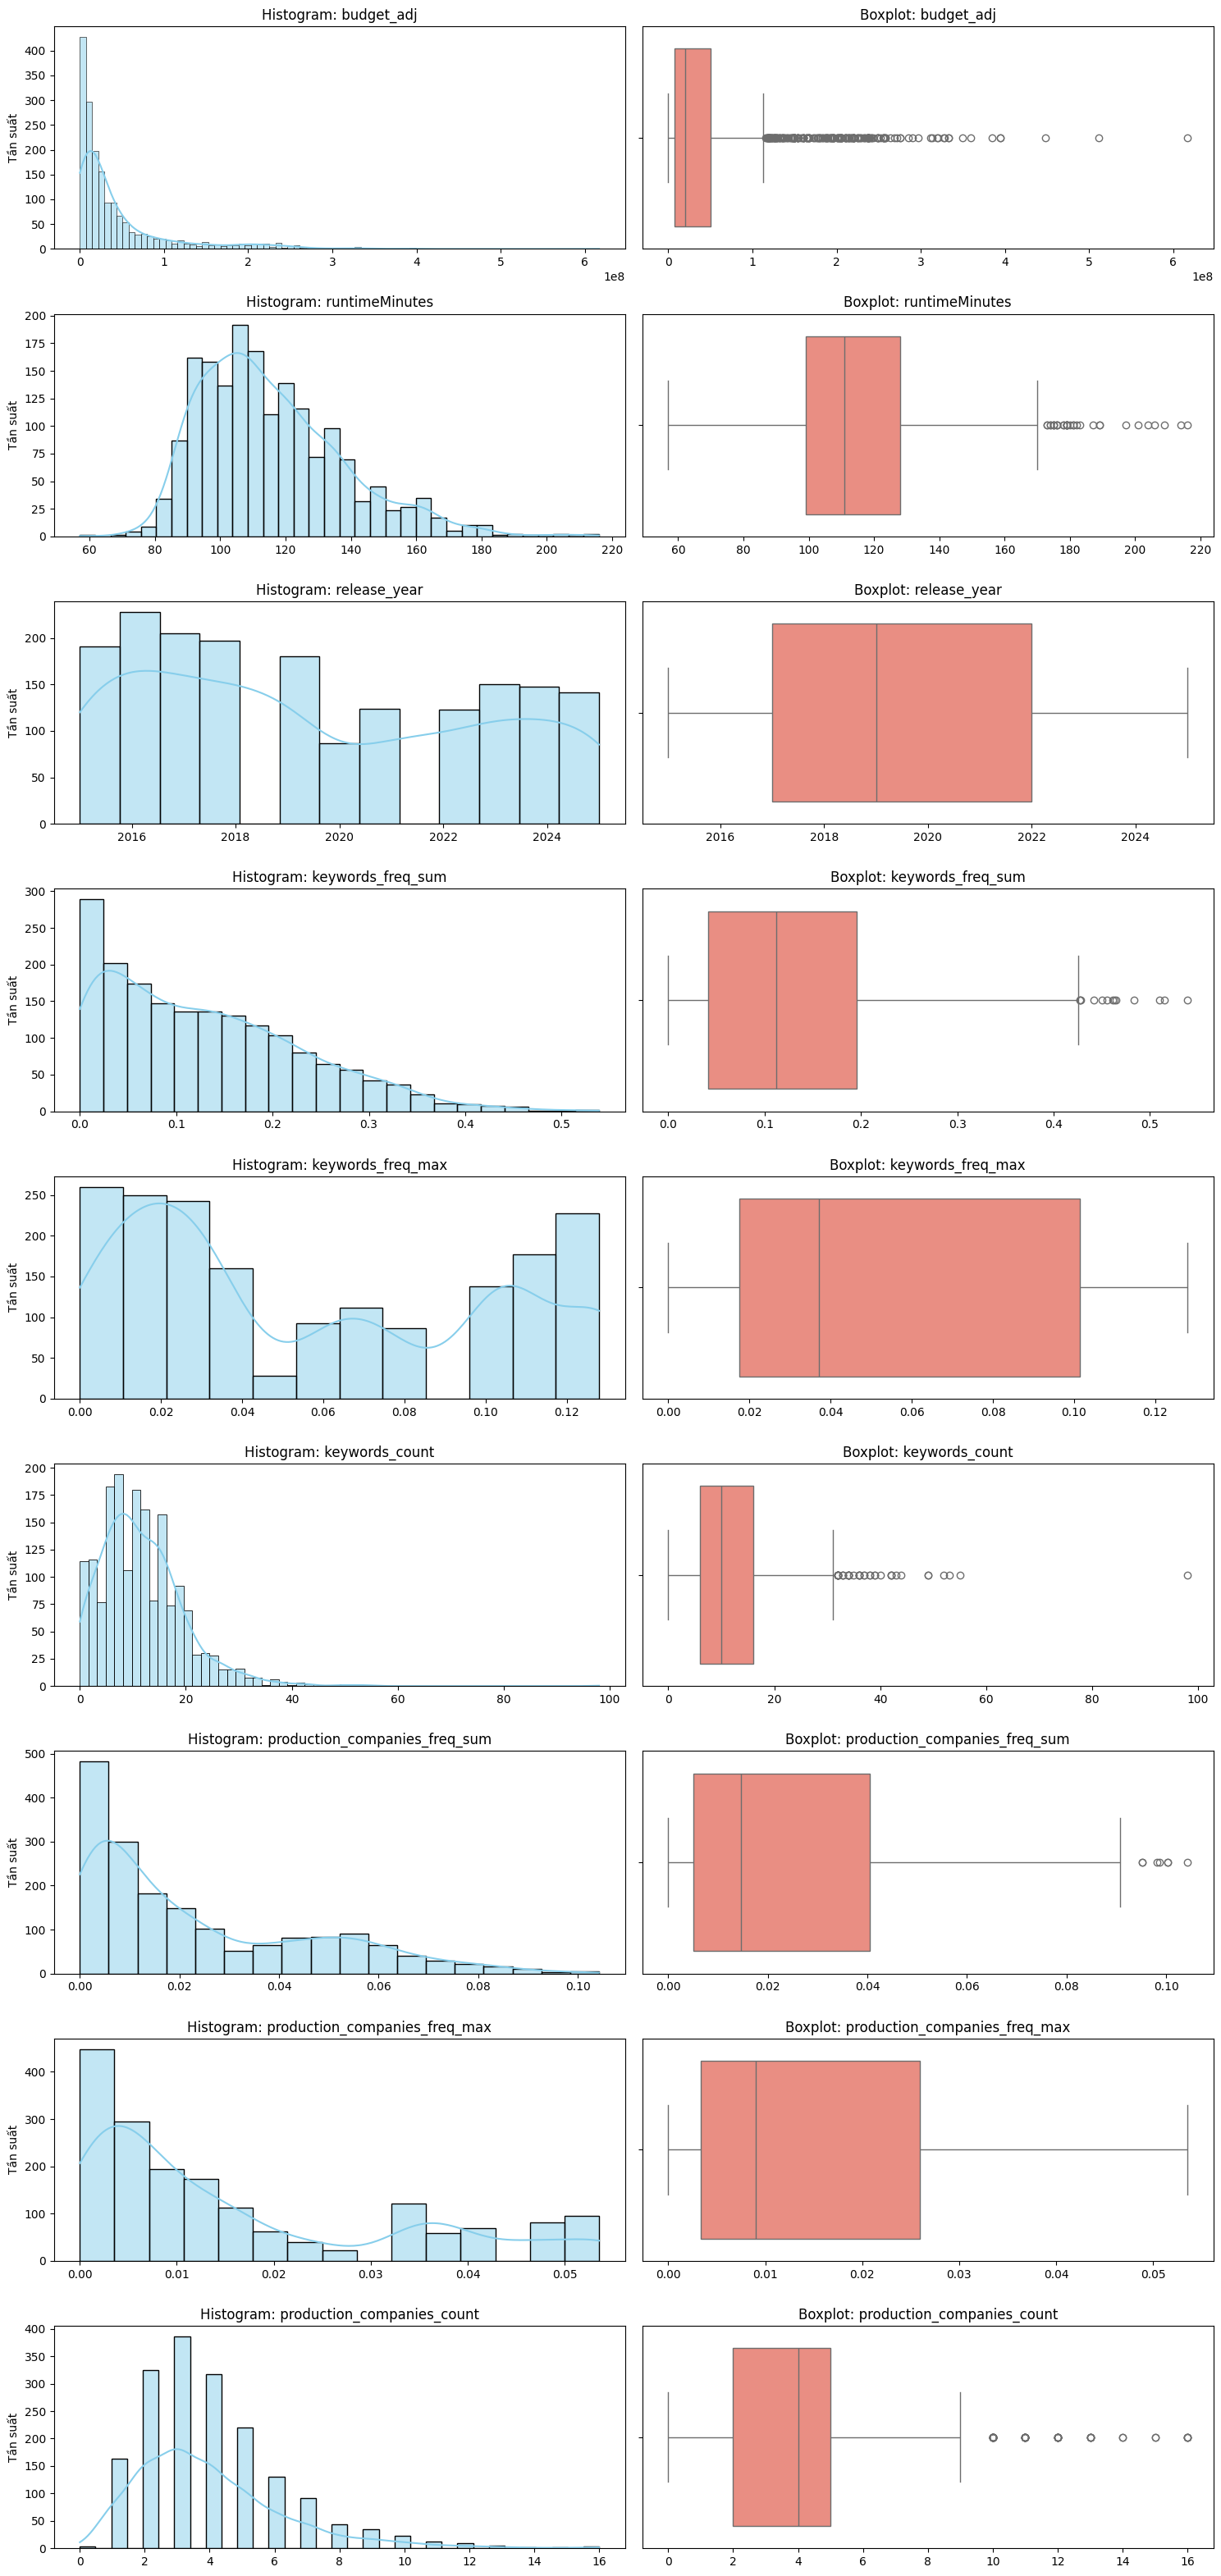

In [96]:
# Kiểm tra phân phối, skewness
# Bỏ qua: binary/OHE columns, target, tconst
numeric_cols = [
    'budget_adj',
    'runtimeMinutes',
    'release_year',
    'keywords_freq_sum',
    'keywords_freq_max',
    'keywords_count',
    'production_companies_freq_sum',
    'production_companies_freq_max',
    'production_companies_count'
]

print("Skewness các cột numeric:")
print(df_train[numeric_cols].skew().round(3))

n_features = len(numeric_cols)
fig, axes = plt.subplots(n_features, 2, figsize=(15, n_features * 3.5), squeeze=False)

for i, col in enumerate(numeric_cols):
    sns.histplot(df_train[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f"Histogram: {col}")
    axes[i, 0].set_xlabel("")
    axes[i, 0].set_ylabel("Tần suất")
    
    sns.boxplot(x=df_train[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f"Boxplot: {col}")
    axes[i, 1].set_xlabel("")

plt.tight_layout()
plt.show()

**TRANSFORMATION**

Min budget: 1.1002489548223486
Skewness budget_adj (gốc): 2.765
Skewness budget_4root: 0.47


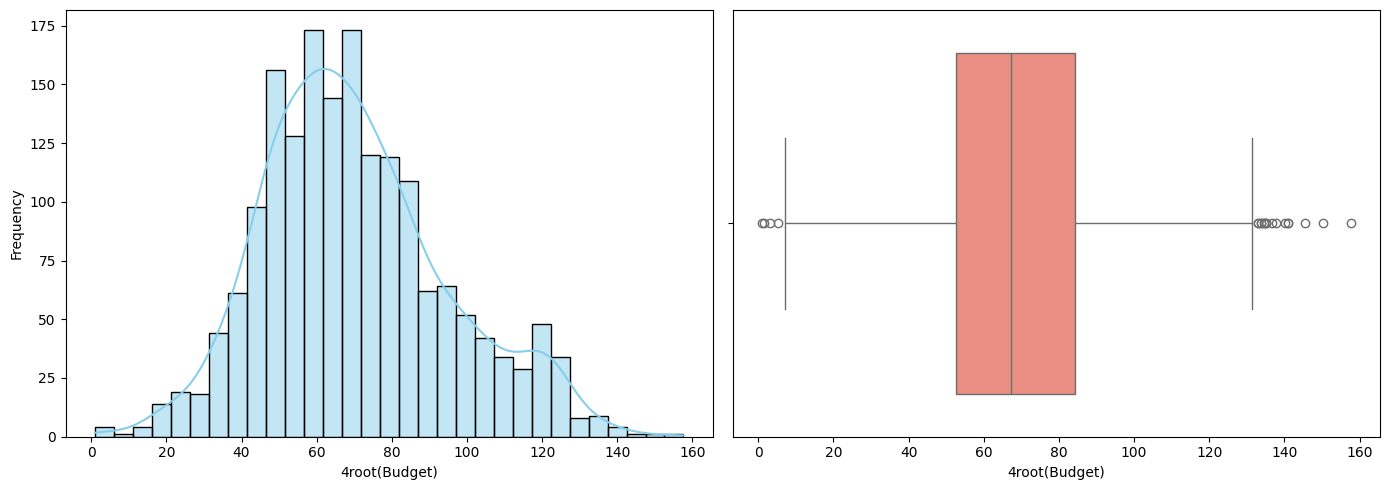

In [97]:
# 1. budget_adj
print(f"Min budget:", df_train['budget_adj'].min())

df_train['budget_4root'] = np.power(df_train['budget_adj'], 0.25)
df_test['budget_4root'] = np.power(df_test['budget_adj'], 0.25)

print("Skewness budget_adj (gốc):", df_train['budget_adj'].skew().round(3))
print("Skewness budget_4root:", df_train['budget_4root'].skew().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_train['budget_4root'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_xlabel('4root(Budget)')
axes[0].set_ylabel('Frequency')
sns.boxplot(x=df_train['budget_4root'], ax=axes[1], color='salmon')
axes[1].set_xlabel('4root(Budget)')

plt.tight_layout()
plt.show()

Do log nén quá mạnh các giá trị lớn, làm phân phối từ lệch phải sang lệch trái, nhóm quyết định dùng căn bậc 4 cho budget.

runtimeMinutes lệch không quá nặng, không cần transform. Có một số outlier nên dùng RobustScaler.

release_year chỉ có 11 giá trị từ 2015-2025, không transform, dùng MinMaxScaler.

--- keywords_freq_sum ---
Skewness keywords_freq_sum (gốc): 0.778
Skewness keywords_freq_sum_sqrt: -0.194


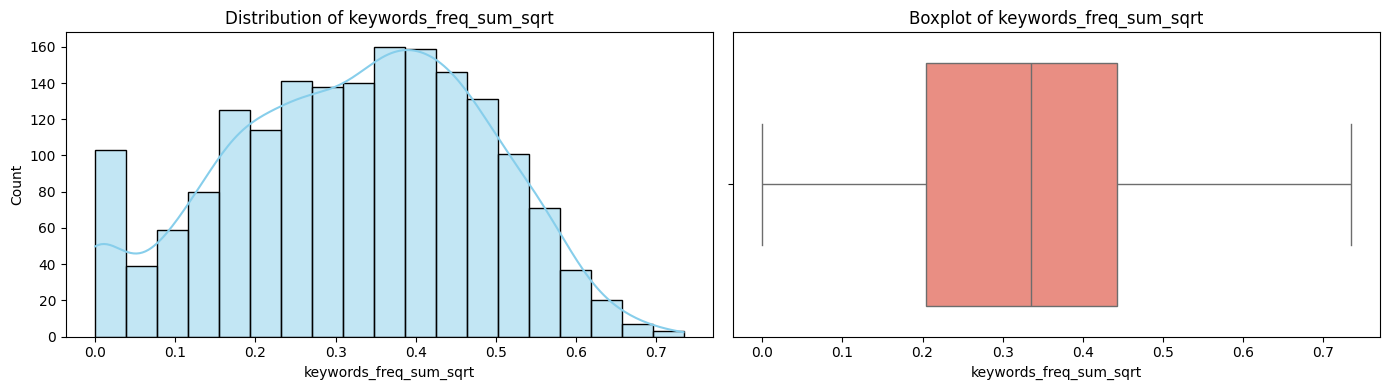

--- keywords_count ---
Skewness keywords_count (gốc): 1.689
Skewness keywords_count_sqrt: -0.22


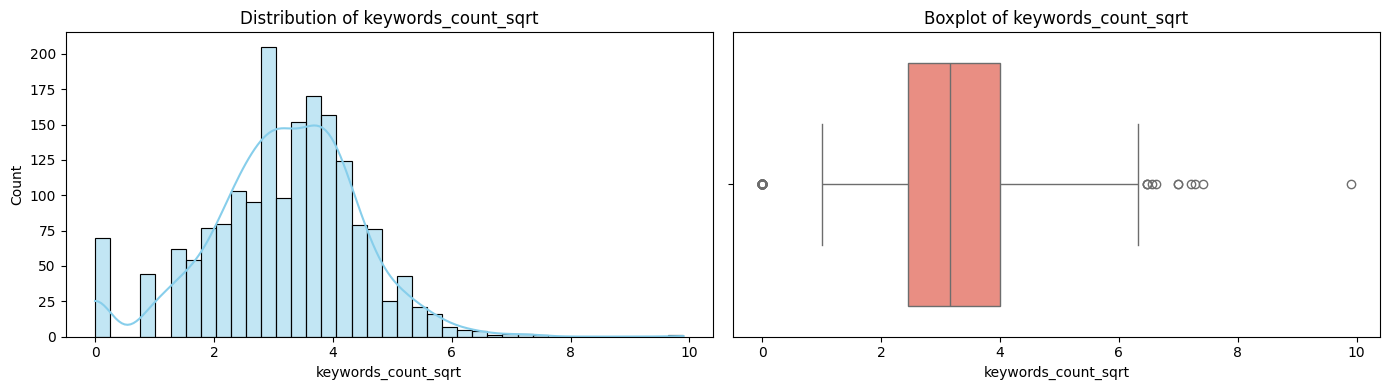

--- production_companies_freq_sum ---
Skewness production_companies_freq_sum (gốc): 1.011
Skewness production_companies_freq_sum_sqrt: 0.23


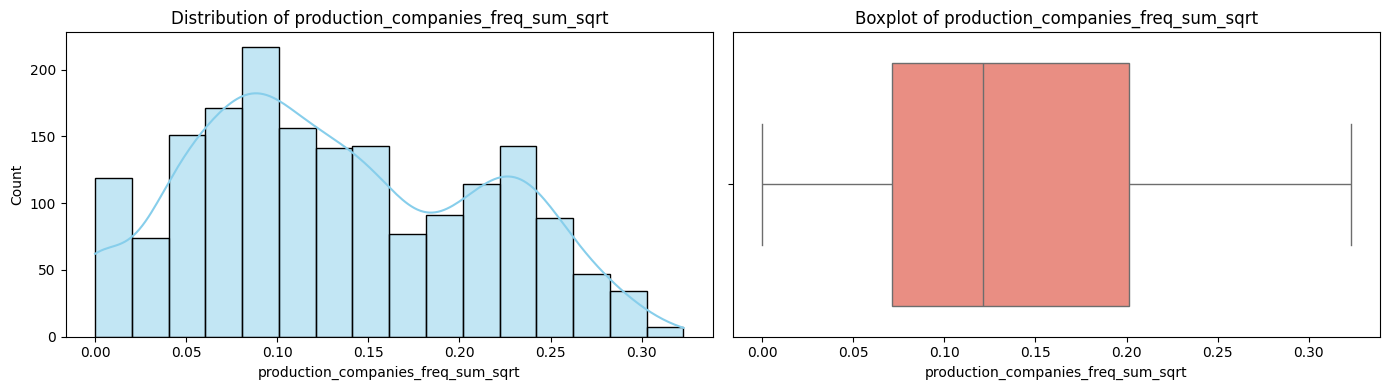

--- production_companies_freq_max ---
Skewness production_companies_freq_max (gốc): 1.009
Skewness production_companies_freq_max_sqrt: 0.332


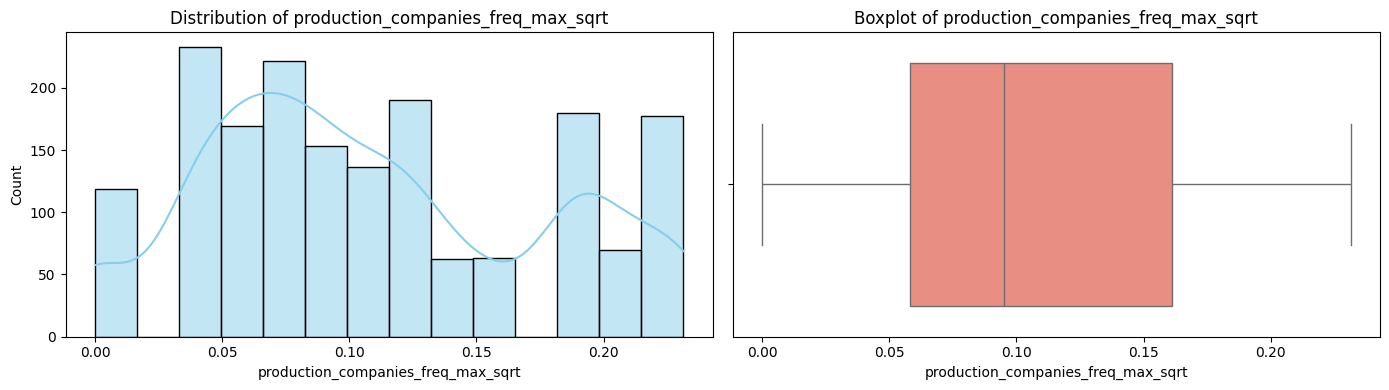

--- production_companies_count ---
Skewness production_companies_count (gốc): 1.408
Skewness production_companies_count_log: 0.027


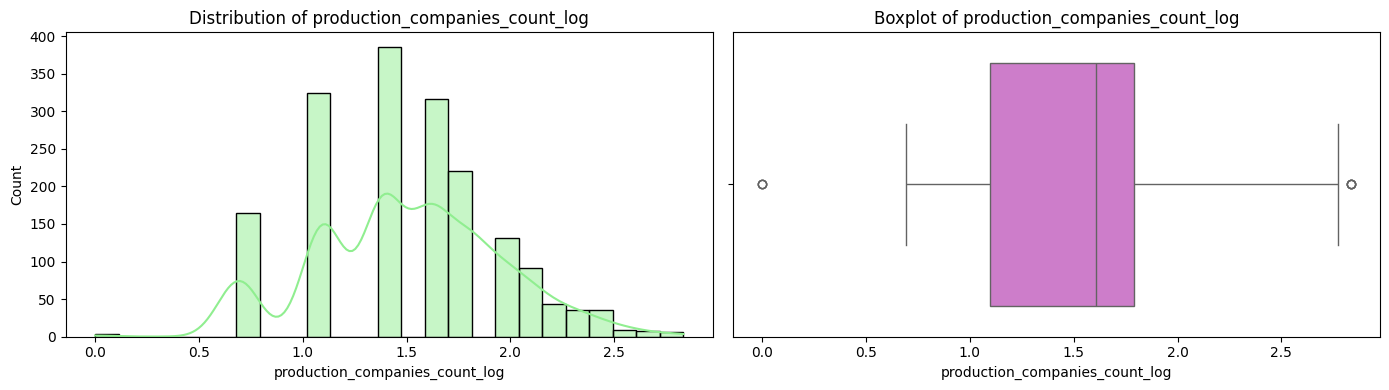

In [98]:
cols_sqrt = ['keywords_freq_sum', 'keywords_count', 'production_companies_freq_sum', 'production_companies_freq_max']

for col in cols_sqrt:
    new_col = col + '_sqrt'
    df_train[new_col] = np.sqrt(df_train[col])
    df_test[new_col] = np.sqrt(df_test[col])
    
    print(f"--- {col} ---")
    print(f"Skewness {col} (gốc):", df_train[col].skew().round(3))
    print(f"Skewness {new_col}:", df_train[new_col].skew().round(3))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(df_train[new_col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribution of {new_col}')
    sns.boxplot(x=df_train[new_col], ax=axes[1], color='salmon')
    axes[1].set_title(f'Boxplot of {new_col}')
    plt.tight_layout()
    plt.show()

cols_log = ['production_companies_count']

for col in cols_log:
    new_col = col + '_log'
    df_train[new_col] = np.log1p(df_train[col])
    df_test[new_col] = np.log1p(df_test[col])
    
    print(f"--- {col} ---")
    print(f"Skewness {col} (gốc):", df_train[col].skew().round(3))
    print(f"Skewness {new_col}:", df_train[new_col].skew().round(3))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(df_train[new_col], kde=True, ax=axes[0], color='lightgreen')
    axes[0].set_title(f'Distribution of {new_col}')
    sns.boxplot(x=df_train[new_col], ax=axes[1], color='orchid')
    axes[1].set_title(f'Boxplot of {new_col}')
    plt.tight_layout()
    plt.show()

keywords_freq_sum                0.778

Log không hiệu quả với range [0, 0.5] vì với x << 1, log1p(x) ~ x, gần như không thay đổi phân phối. Sqrt co phần đuôi phải lại hiệu quả hơn trong range này: sqrt(0.5) = 0.707 nhưng sqrt(0.01) = 0.1, kéo giãn vùng giá trị nhỏ, nén vùng lớn. Kết quả skewness về -0.194, phân phối gần symmetric, không có outlier.

keywords_freq_max                0.385

Gần như không lệch, giữ nguyên để không thay đổi hình dạng phân phối.

keywords_count                   1.689

Thử log cho skewness -1.078, phân phối bị kéo ngược sang lệch trái. Có thể do có một số dòng keywords_count = 0, log1p(0) = 0 giữ nguyên nhóm này nhưng co mạnh các giá trị lớn, làm lệch cân bằng. Sqrt xử lý nhẹ hơn, skewness về -0.22, phân phối symmetric, outlier ít

production_companies_freq_sum    1.011

Range [0, 0.1], log không hiệu quả. Sqrt đưa skewness về 0.230.

production_companies_freq_max    1.009

Range [0, 0.055], log không hiệu quả. Sqrt đưa skewness về 0.332.

production_companies_count       1.408

Range đủ lớn (1–16) để log phát huy hiệu quả, log1p(1)=0.69, log1p(16)=2.83. Skewness về 0.027. Sqrt cải thiện skewness không bằng log1p đối với biến này nên ưu tiên log.

**NORMALIZATION**

In [99]:
# # StandardScaler: Dành cho dữ liệu liên tục, xấp xỉ phân phối chuẩn
# standard_cols = [
# ]

# RobustScaler: Dành cho dữ liệu liên tục, lệch nặng và chứa điểm dị biệt
robust_cols = [
    'budget_4root',
    'runtimeMinutes',
    'keywords_freq_sum_sqrt',
    'keywords_freq_max',
    'keywords_count_sqrt',
    'production_companies_freq_sum_sqrt',
    'production_companies_freq_max_sqrt',
    'production_companies_count_log'
]

# MinMaxScaler: Dành cho dữ liệu có giới hạn cứng, không có outlier
minmax_cols = [
    'release_year',
]

scaler_standard = StandardScaler()
scaler_robust = RobustScaler()
scaler_minmax = MinMaxScaler()

# df_train[standard_cols] = scaler_standard.fit_transform(df_train[standard_cols])
# df_test[standard_cols] = scaler_standard.transform(df_test[standard_cols])

df_train[robust_cols] = scaler_robust.fit_transform(df_train[robust_cols])
df_test[robust_cols] = scaler_robust.transform(df_test[robust_cols])

df_train[minmax_cols] = scaler_minmax.fit_transform(df_train[minmax_cols])
df_test[minmax_cols] = scaler_minmax.transform(df_test[minmax_cols])

print("Scaling hoàn tất.")
print("\nThống kê sau scale (train):")
print(df_train[robust_cols + minmax_cols].describe().round(3))

Scaling hoàn tất.

Thống kê sau scale (train):
       budget_4root  runtimeMinutes  keywords_freq_sum_sqrt  \
count      1774.000        1774.000                1774.000   
mean          0.095           0.156                  -0.054   
std           0.781           0.760                   0.672   
min          -2.095          -1.862                  -1.407   
25%          -0.460          -0.414                  -0.549   
50%           0.000           0.000                   0.000   
75%           0.540           0.586                   0.451   
max           2.863           3.621                   1.677   

       keywords_freq_max  keywords_count_sqrt  \
count           1774.000             1774.000   
mean               0.226                0.014   
std                0.523                0.810   
min               -0.443               -2.040   
25%               -0.235               -0.460   
50%                0.000                0.000   
75%                0.765                0.

StandardScaler giả định phân phối xấp xỉ chuẩn (skewness gần 0, không có outlier đáng kể). StandardScaler nhạy cảm với outlier vì dùng mean và std. Không có biến phù hợp dùng StandardScaler vì phân phối không chuẩn.

RobustScaler dùng median và IQR thay vì mean và std, không bị ảnh hưởng bởi outlier, phù hợp cho phân phối lệch sau transform.

- budget_4root: Vẫn còn outlier nhẹ.
- runtimeMinutes: Phân phối gần chuẩn nhưng có outlier >180 phút. RobustScaler an toàn hơn.
- keywords_freq_sum_sqrt: Không có outlier rõ trong boxplot nhưng không đảm bảo normal.
- keywords_freq_max: StandardScaler không phù hợp vì hình dạng phân phối.
- keywords_count_sqrt: Có outlier rõ ở boxplot (điểm ~10). RobustScaler xử lý outlier tốt hơn.
- production_companies_freq_sum_sqrt: StandardScaler không phù hợp vì hình dạng phân phối.
- production_companies_freq_max_sqrt: StandardScaler không phù hợp vì hình dạng phân phối.
- production_companies_count_log: Hình dạng phân phối chưa đảm bảo chuẩn, dùng RobustScaler để nhất quán toàn bộ nhóm frequency variables.

MinMaxScaler:

release_year: Biến rời rạc với 11 giá trị cố định (2015–2025), không có outlier theo nghĩa thống kê. MinMaxScaler map về [0, 1] với khoảng cách đều nhau giữa các năm được bảo toàn. StandardScaler, RobustScaler không bảo toàn khoảng cách tuyến tính.

In [100]:
cols_to_drop = [
    'budget_adj',
    'keywords_freq_sum',
    'keywords_count',
    'production_companies_freq_sum',
    'production_companies_freq_max',
    'production_companies_count'
]
df_train = df_train.drop(columns=cols_to_drop, errors='ignore')
df_test = df_test.drop(columns=cols_to_drop, errors='ignore')

In [101]:
print("=== TRAIN ===")
print("Shape:", df_train.shape)
print("Missing:", df_train.isnull().sum().sum())

print("\n=== TEST ===")
print("Shape:", df_test.shape)
print("Missing:", df_test.isnull().sum().sum())

print("\nProfitable distribution - train:", df_train['profitable'].value_counts(normalize=True).round(3).to_dict())
print("Profitable distribution - test:", df_test['profitable'].value_counts(normalize=True).round(3).to_dict())

train_final = df_train.drop(columns=['tconst'])
test_final = df_test.drop(columns=['tconst'])

train_final.to_csv(os.path.join(PROCESSED_DATA_PATH, 'movie_train.csv'), index=False)
test_final.to_csv(os.path.join(PROCESSED_DATA_PATH, 'movie_test.csv'), index=False)

print(f"Đã lưu movie_train.csv - shape: {train_final.shape}")
print(f"Đã lưu movie_test.csv - shape: {test_final.shape}")
print(f"\nFeatures cuối ({train_final.shape[1] - 1} features + 1 target):")
feature_cols = [c for c in train_final.columns if c != 'profitable']
print(feature_cols)

=== TRAIN ===
Shape: (1774, 54)
Missing: 0

=== TEST ===
Shape: (444, 54)
Missing: 0

Profitable distribution - train: {0: 0.607, 1: 0.393}
Profitable distribution - test: {0: 0.604, 1: 0.396}
Đã lưu movie_train.csv - shape: (1774, 53)
Đã lưu movie_test.csv - shape: (444, 53)

Features cuối (52 features + 1 target):
['runtimeMinutes', 'release_year', 'has_us_cert', 'cert_G_PG', 'cert_PG-13', 'cert_R_NC-17', 'cert_NR', 'lang_en', 'lang_fr', 'lang_hi', 'lang_other', 'country_FR', 'country_GB', 'country_IN', 'country_US', 'country_other', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'genre_Adventure', 'genre_Fantasy', 'genre_Animation', 'genre_Drama', 'genre_Horror', 'genre_Action', 'genre_Comedy', 'genre_History', 'genre_Western', 'genre_Thriller', 'genre_Crime', 'genre_Sci-Fi', 'genre_Mystery', 'genre_Music', 'genre_Romance', 'genre_Family', 'genre_War', 'keywords_freq_max', 'budget_4root', 'keywor